<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**

- En el dominio del tiempo la amplirud de la señal debería cambiar a lo largo del tiempo, cosa que se pueda reconocer la morfología, la periodicidad, duración y los eventos transitorios. En cuanto a frecuencia es identificar los componentes que forman la señal y la magnitud en la que contribuyen, con esto se puede reconocer mejor las frecuencias dominantes, y también el ruido.

In [45]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 128*60*60
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [46]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


In [47]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [49]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [50]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 39
Anotaciones del registro 16272: 28
Anotaciones del registro 16420: 35


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [51]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?
 Frecuencia de muestreo del registro 16265 = 128Hz
 Frecuencia de muestreo del registro 16272 = 128Hz
 Frecuencia de muestreo del registro 16420 = 128Hz
2. ¿Los tres registros tienen la misma frecuencia de muestreo?
 Sí, los tres tregistros presentan la misma frecuencia de muestreo.
3. ¿Cuántos canales posee cada registro?
 Los tres registros presentan 2 canales cada uno.
4. ¿Qué señal corresponde al canal `0`?
 La señal ECG1 tiene 3600 número de muestras.
5. ¿Cuántas muestras contiene cada registro?
 Los tres registros
6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?

\[N=f_s\,T\]
Por lo tanto, si `fs = 360 Hz`, entonces:

\[
T=\frac{3600}{360}=10\;s
\]

Sin embargo, `fs = 128 Hz`, por lo que las 3600 muestras cargadas representan:

\[
T=\frac{3600}{128}=28.125\;s
\]


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [52]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


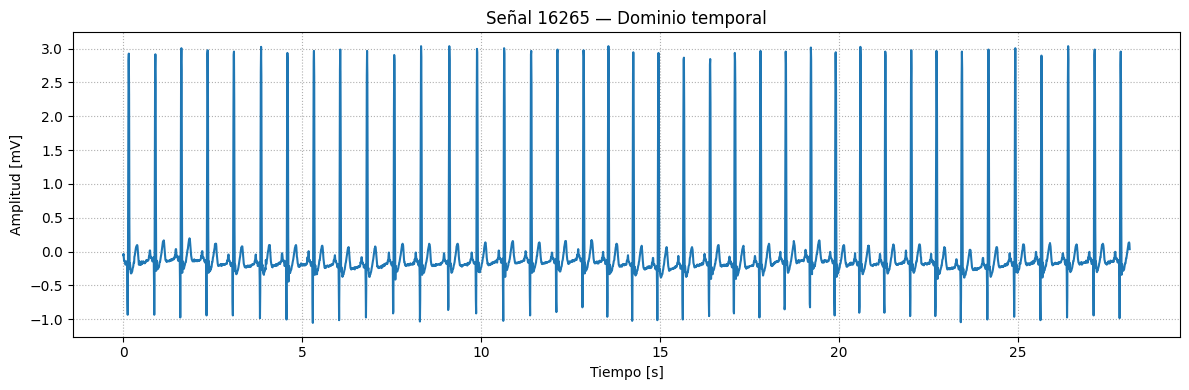

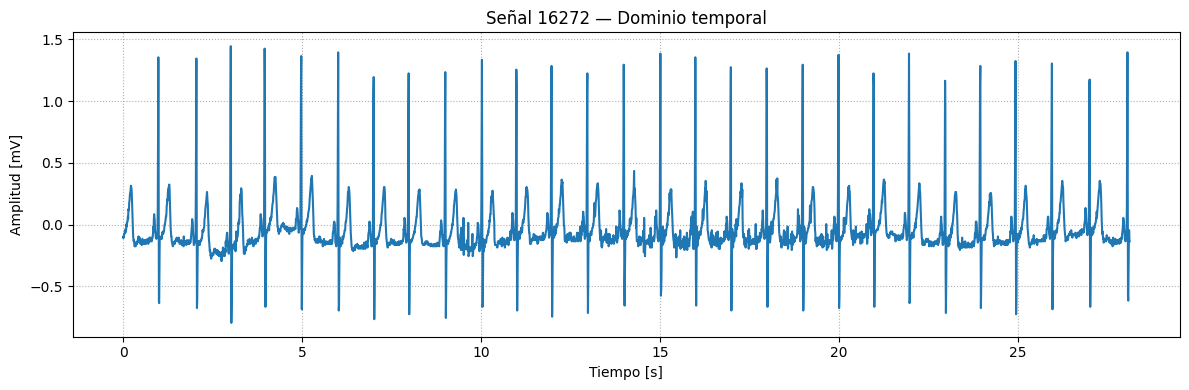

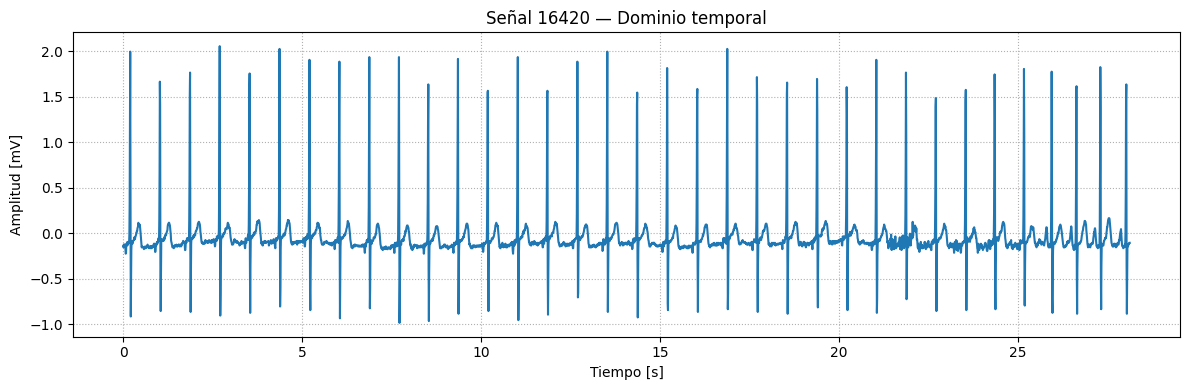

In [53]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?
- Sí porque las 3 corresponden a señales ECG.
2. ¿Cuál presenta mayor variación de amplitud?
- La señal 16265 porque tiene picos cercanos a +3mV y -1mV.
3. ¿Se observan patrones periódicos?
- Sí, porque en los 3 registros hay complejos que se repiten casi periódicamente.
4. ¿Se identifican eventos o cambios particulares?
- Sí. En `16265` hay complejos de gran amplitud y variaciones pequeñas. En `16272` se ve más ruidoso y también tiene variaciones visibles. En `16420` complejos relativamente regulares, pero hacia el final se incrementa la variabilidad de la señal.
5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?
- La amplitud de la señal, también la duración del segmento, regularidad de los ciclos y también la separación temporal entre eventos, pero de todas maneras no muestra directamente como es que se distribuye la energía entre las frecuencias.


# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [54]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [55]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


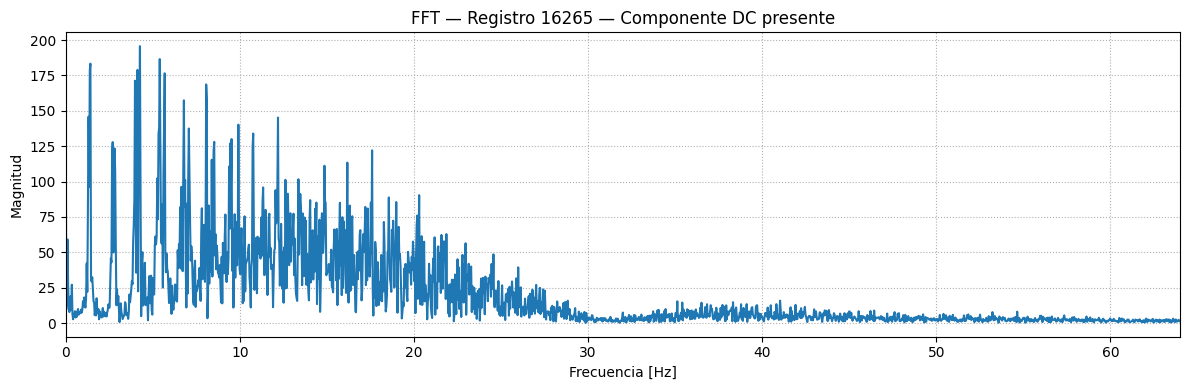

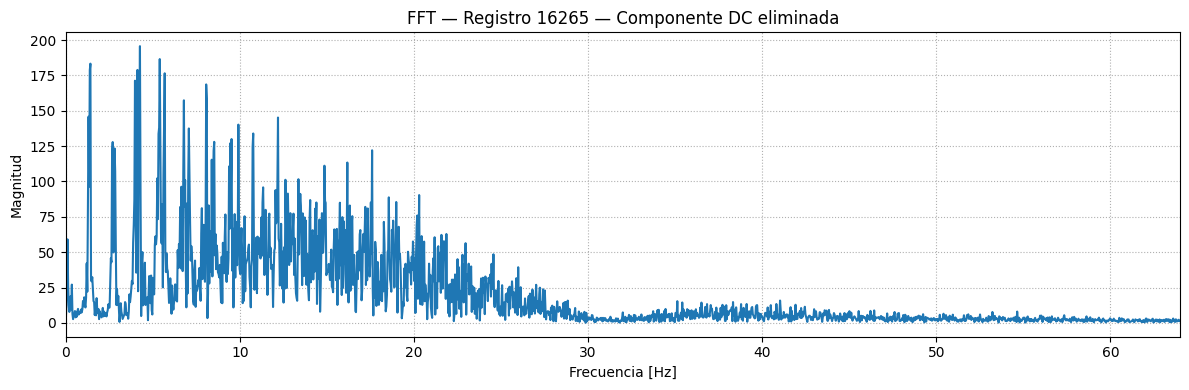

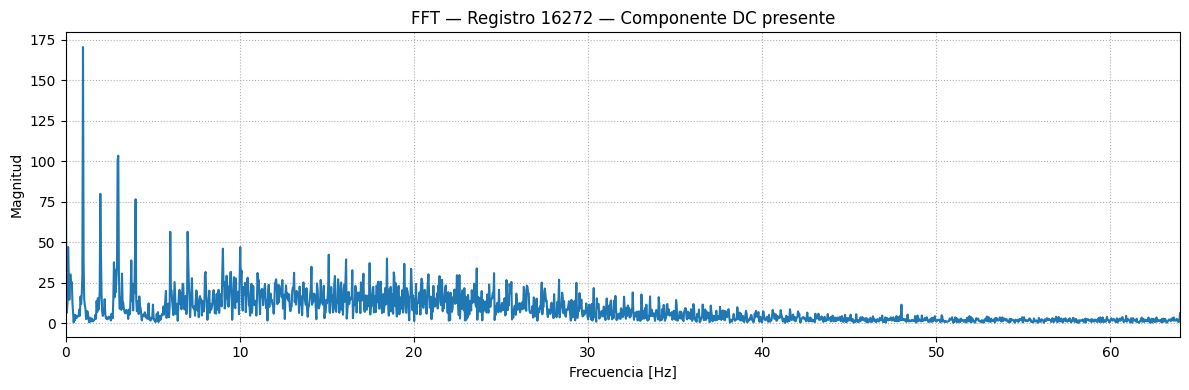

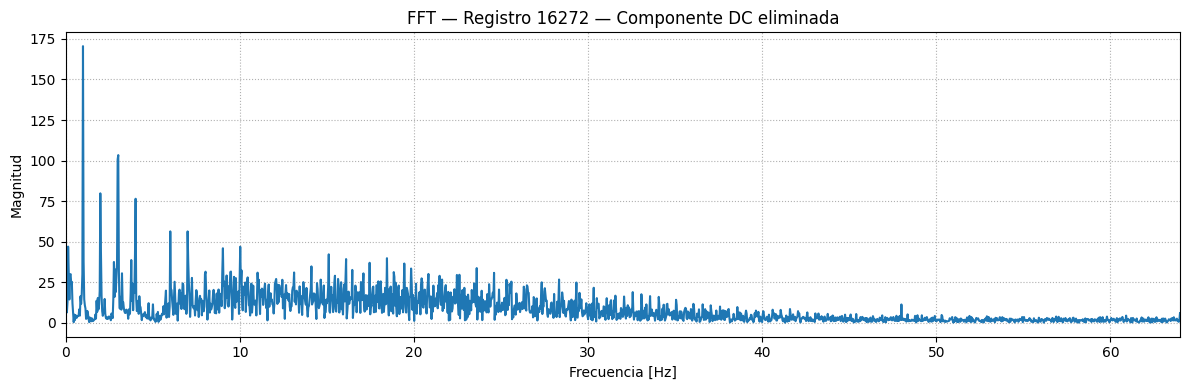

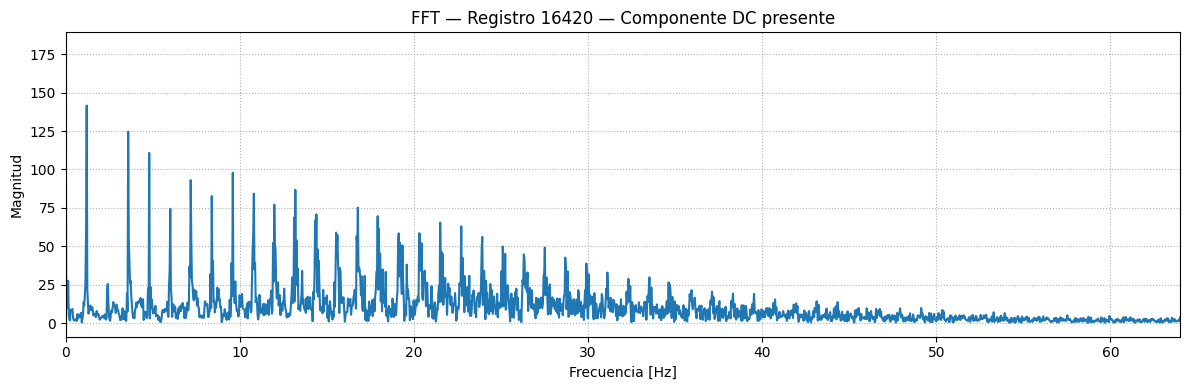

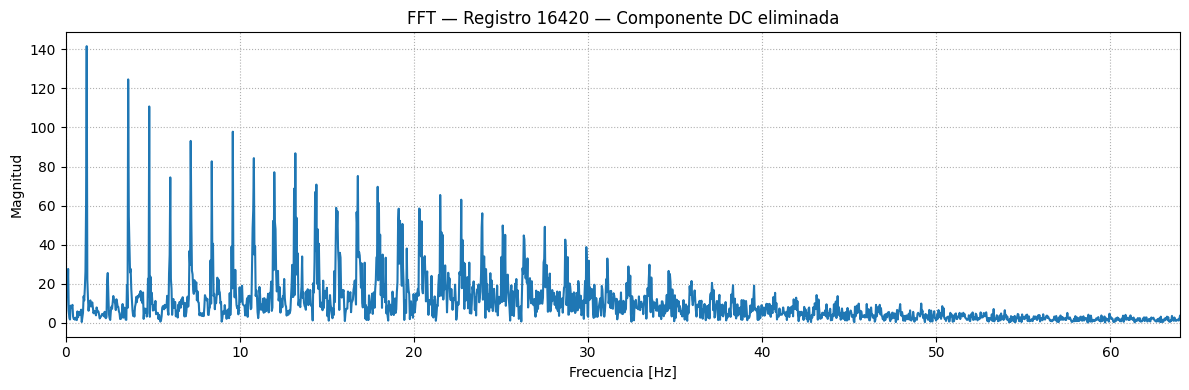

In [56]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?
- disminuye hasta casi 0, porque cuando se hace el "x - mean(x)" la nueva señal queda con una media casi nula.
2. ¿Qué diferencias observa entre los espectros de los tres registros?
- uno muestra numerosos picos de magnitud distribuidos entre bajas y medias frecuencias, el otro presenta una frecuencia dominante cercana a 0.996 Hz con energía distribuida en las frecuencias superiores, el último (16420) muestra más picos armónicos y ordenados con una frecuencia dominante de 1.209 Hz.
3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?
- por debajo de 30 Hz
4. ¿Por qué la FFT no conserva directamente la información temporal?
- porque analiza la FFT como una sola señal completa, por ello sí se permite saber qué frecuencias son las que están presentes pero no indica en que instante aparece cada una.
5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?
- cuando se observa en el dominio frecuencial se puede identificar los armónicos y también bandas donde se concentra la energía y el ruido.

# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [57]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 4.267 Hz, magnitud = 195.708
Registro 16272: frecuencia dominante = 0.996 Hz, magnitud = 170.507
Registro 16420: frecuencia dominante = 1.209 Hz, magnitud = 141.585


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [58]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [59]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


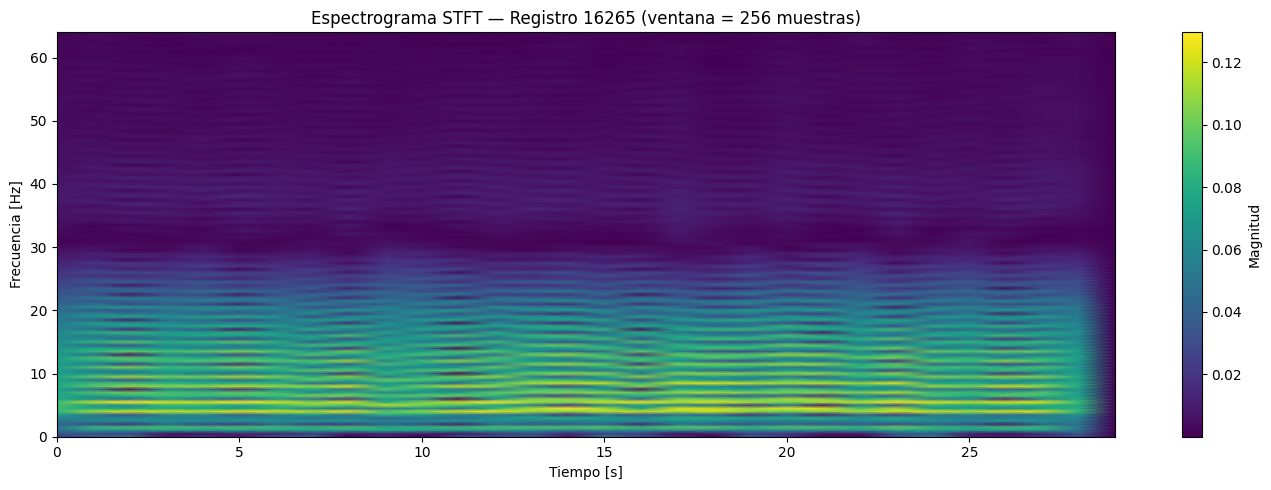

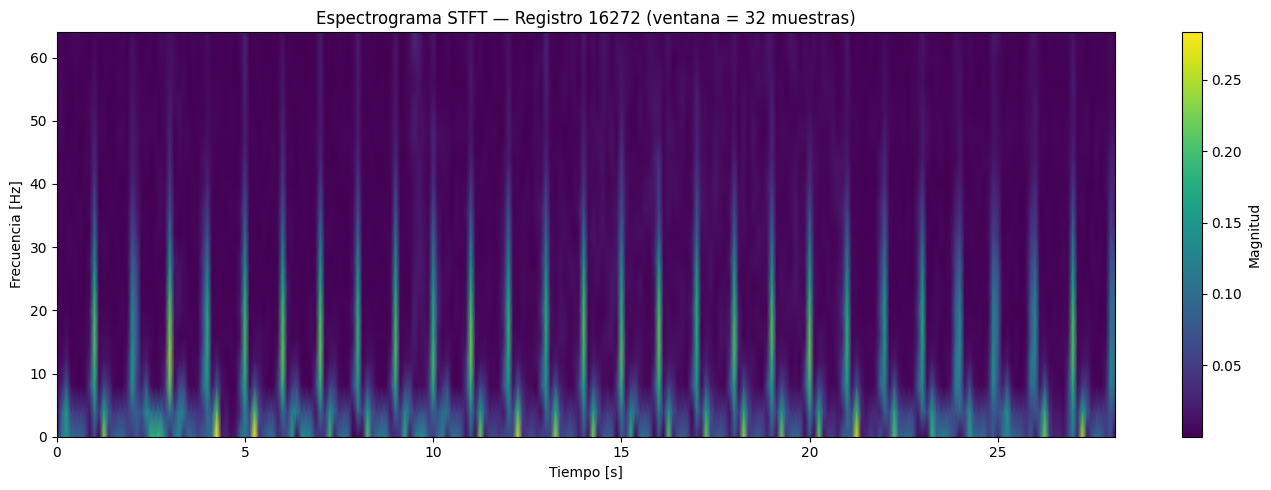

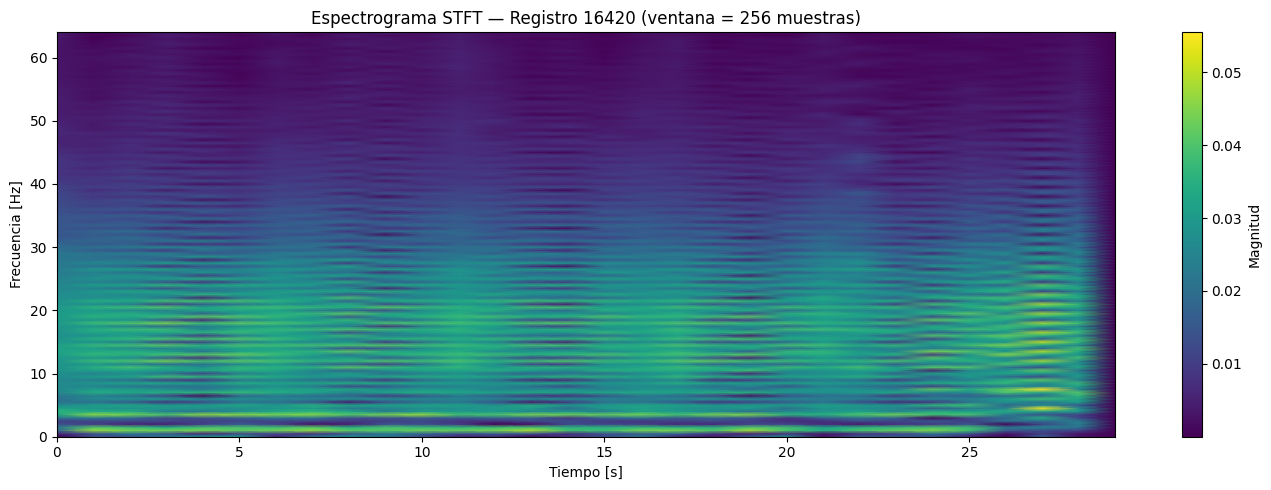

In [60]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?
- con la STFT podemos conocer cómo es que cambia el contenido frecuencial de la señal a lo largo del tiempo mientras que con la FFT se puede identificar las frecuencias que están presentes en el segmento analizado, por ello con la STFT vemos en que momento aparecen/desaparecen esas componentes.
2. ¿En qué momentos se observan cambios de energía?
- En los instantes que están asociados a los eventos repetitivos del ECG, porque aparecen en los espectrogramas como zonas de mayor intensidad.
3. ¿Qué diferencias observa entre los tres espectrogramas?
- Los tres muestran que su energía mayormente está entre las frecuencias bajas y medias, pero tienen distribución temporal diferente, esto no solo por la señal sino por el tamaño de ventana que se usa en la STFT.
4. ¿Por qué el registro `16272` utiliza una ventana de 32 muestras?
- Porque se quiere obtener una mejor resolución temporal para poder hallar y localizar mejor los eventos de corta duración, ya que como la frecuencia de muestreo es de 128 Hz su periodo es de alrededor de 0.25s.
5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?
- nos puede dar mejor resolución frecuencial pero reduciría lo que es la resolución temporal así que si se quiere identificar eventos breves se hará más difícil.
6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?
- acá ocurre lo contrario porque si bien se mejora la resolución temporal, lo que va a disminuir es la resolución frecuencial.


# 13. Comparación de los tres registros

Complete la siguiente tabla a partir de los resultados obtenidos.

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo | 128 Hz | 128 Hz | 128 Hz |
| Número de muestras | 3600 | 3600 | 3600 |
| Número de canales | 2 | 2 | 2 |
| Canal analizado | ECG1 | ECG1 | ECG1 |
| Duración analizada | 28.125 s | 28.125 s | 28.125 s |
| Amplitud observada | Mayor excursión; aprox. −1 a 3 mV | Menor excursión; aprox. −0.8 a 1.5 mV | Intermedia; aprox. −1 a 2.1 mV |
| Componente DC | Se elimina al restar la media | Se elimina al restar la media | Se elimina al restar la media |
| Frecuencia dominante calculada | 4.267 Hz | 0.996 Hz | 1.209 Hz |
| Ventana STFT | 256 muestras = 2 s | 32 muestras = 0.25 s | 256 muestras = 2 s |
| Comportamiento STFT | Energía predominante por debajo de ~25–30 Hz, con variaciones suaves en el tiempo | Eventos verticales repetitivos bien localizados temporalmente | Energía predominantemente en bajas-medias frecuencias, con aumento visible hacia el final |
| Observaciones | Mayor amplitud y espectro con múltiples componentes | Mejor localización temporal por la ventana corta | Patrón espectral más armónico/estructurado |

### Discusión

Explique:

El registro **16265** presenta la mayor variación de amplitud en el dominio temporal. Aunque las tres señales muestran complejos repetitivos, sus amplitudes, forma de onda y nivel de variación no son exactamente idénticos.

En el dominio frecuencial, `16265` posee múltiples componentes de magnitud y su máximo calculado se encuentra en 4.267 Hz; `16272` presenta una dominante de 0.996 Hz; y `16420` una dominante de 1.209 Hz la cual también tiene una estructura de armónicos más evidente. Entonces se demuestra que las señales visualmente parecidas en el tiempo pueden tener distribuciones de energía diferentes.

La STFT le añade la localización temporal de las componentes frecuenciales. En `16272`, la ventana corta de 32 muestras permite distinguir con claridad eventos breves como franjas verticales. En `16265` y `16420`, las ventanas de 256 muestras ofrecen mayor detalle frecuencial, pero menor precisión temporal.

Por lo tanto, el tamaño de ventana modifica directamente el compromiso tiempo-frecuencia, haciendo que una ventana corta mejore la localización temporal y una ventana larga mejore la resolución en frecuencia.

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
Ahora cambiado:
SAMPFROM = 128*60*60
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

1. ¿La morfología cambia?

Sí, en las tres señales hay diferencias — sobre todo en 16265 (desaparecen los latidos reducidos) y 16272 (ondas P/T más definidas).

2. ¿El espectro cambia?

Sí, cambia, pero en distinto grado según la señal:

16420 muestra el cambio más notorio: pasa de un espectro ruidoso y sin estructura clara a uno con armónicos bien definidos — el ritmo se volvió más regular/periódico en el segmento posterior.
16265 muestra un cambio moderado: se extiende la serie armónica, sugiriendo un QRS más consistente sin los latidos anómalos del original.
16272 apenas cambia: el espectro es casi idéntico, reflejando que esta señal mantiene su nivel de ruido característico a lo largo del registro.

3. ¿La STFT muestra nuevos eventos?

16420: sí, muestra un evento nuevo claro — un aumento de energía estructurada hacia el final del segmento (22-28s), que refleja el cambio hacia un ritmo más regular.
16272: el cambio es al revés — desaparecen dos eventos anómalos que sí estaban en el original (18.5s y 27s), en vez de aparecer nuevos.
16265: no aparecen eventos nuevos aislados; el cambio es una intensificación general y uniforme de la estructura ya presente.

4. ¿Qué diferencias encuentra respecto al segmento original?
La señal ECG no es estacionaria a lo largo del registro — segmentos separados por 1 hora muestran morfología, contenido espectral y comportamiento temporal distintos, incluso dentro del mismo paciente/registro.
16265: cambio moderado — desaparecen latidos anómalos puntuales, el espectro se enriquece con más armónicos.
16272: la señal es la más estable entre segmentos en cuanto a nivel de ruido general, pero pierde dos eventos anómalos puntuales.
16420: el cambio más marcado — pasa de un ritmo poco estructurado y ruidoso a uno con espectro y STFT mucho más regulares y energéticos, especialmente notorio hacia el final del segmento posterior.
En conjunto, esto refuerza que el análisis de una sola ventana temporal no es representativo de todo el registro, especialmente en bases de datos de 24 horas como nsrdb, donde el estado fisiológico del paciente (sueño, actividad, etc.) cambia con el tiempo.
---

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```


### Responda

1. ¿Cuál permite observar mejor los eventos temporales?
- La de 32 muestras porque dura menos, entonces permite localizar mejor cuando es que ocurren los cambios.
2. ¿Cuál proporciona mayor detalle en frecuencia?
- El de 256 muestras porque la separación entre bins de frecuencia es pequeña.
3. ¿Cuál considera más apropiada para este registro? Justifique.
- El de 32 muestras porque es el que prioriza la resolución temporal y como mencionaba también hace visible las franjas verticales que se asocian a los cambios rápidos.

---

## Ejercicio 2.3 — Comparación FFT vs. STFT

Explique con sus propias palabras:

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?
- La FFT calcula el contenido de frecuencia utilizando todo el segmento a la vez. Por ello, si una componente aparece solo durante un instante breve, su contribución queda mezclada con el resto de la señal y se pierde la información de cuándo ocurrió. Pero la STFT divide la señal en ventanas sucesivas y calcula un espectro para cada una, así conserva simultáneamente información aproximada de tiempo y frecuencia y permite localizar cambios o eventos transitorios.

nperseg = 32: duración de ventana = 0.250 s, resolución frecuencial aproximada = 4.000 Hz


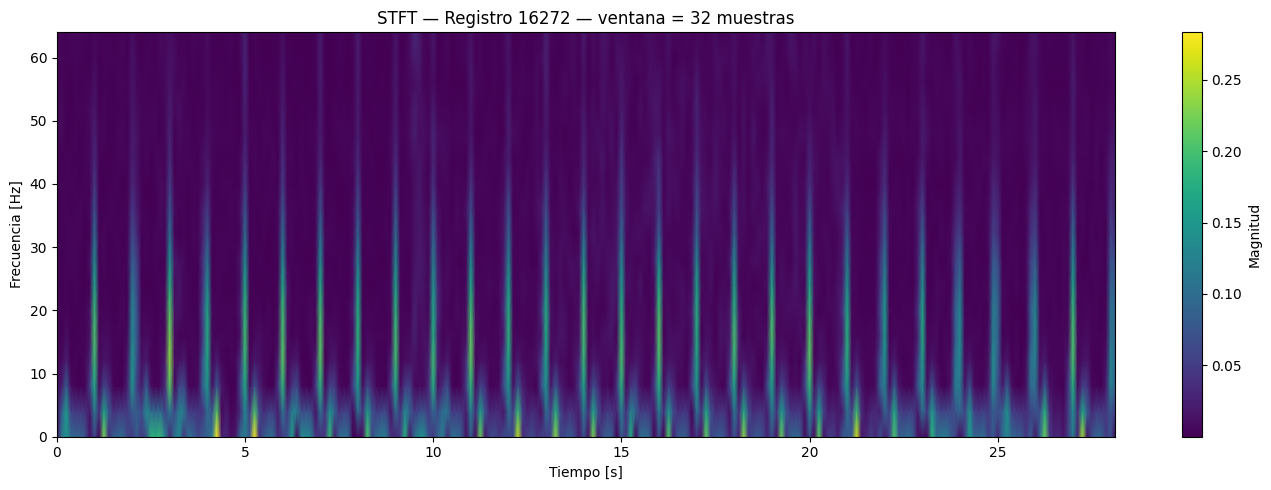

nperseg = 128: duración de ventana = 1.000 s, resolución frecuencial aproximada = 1.000 Hz


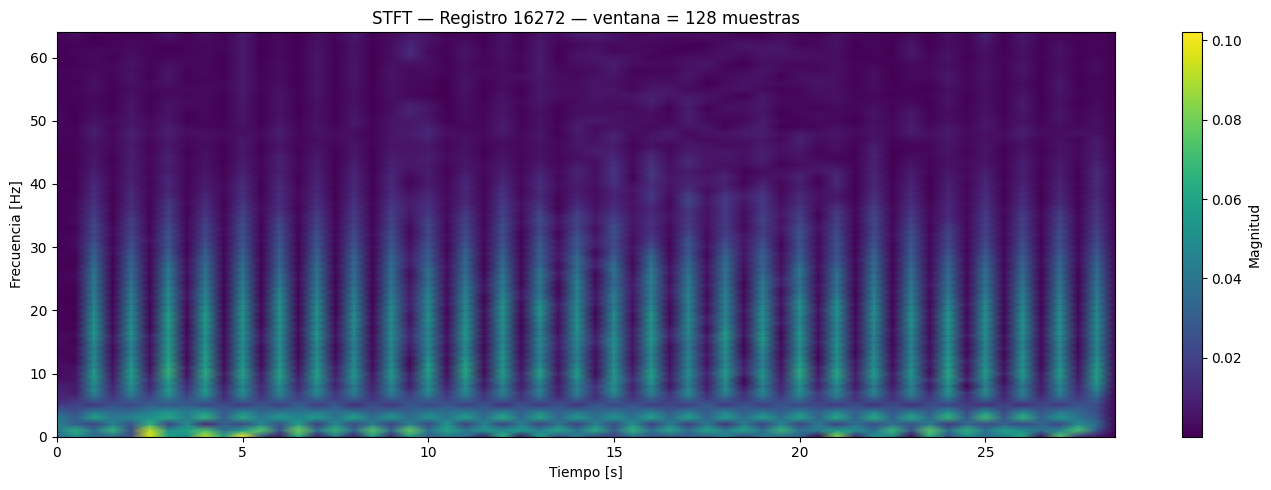

nperseg = 256: duración de ventana = 2.000 s, resolución frecuencial aproximada = 0.500 Hz


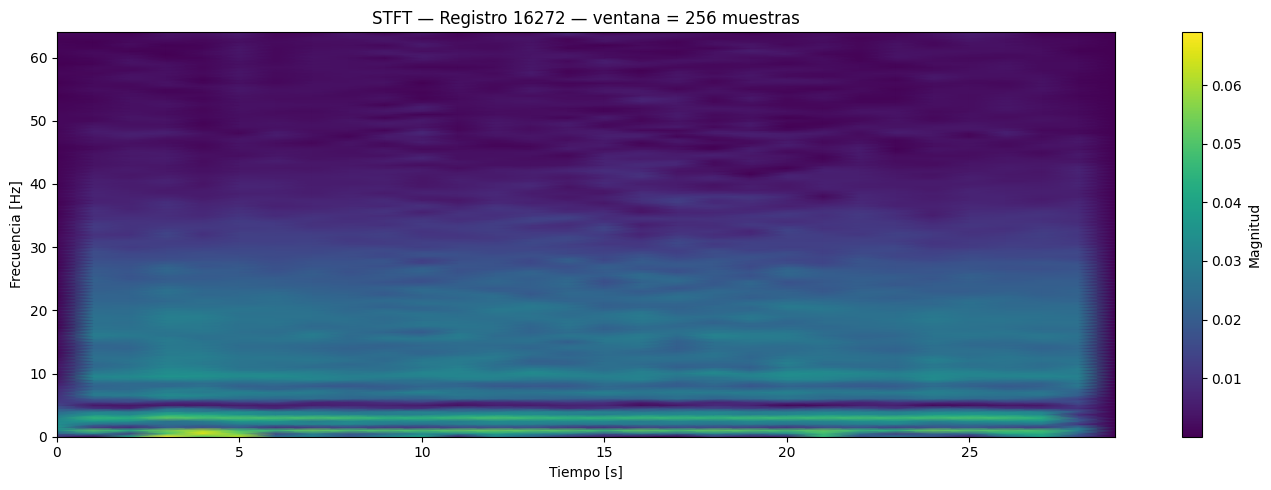

In [61]:
# Registro 16272: 32, 128 y 256 muestras
# ============================================

record_name = "16272"
x = fft_data[record_name]["signal_ac"]
fs = sampling_rates[record_name]

for nperseg in [32, 128, 256]:
    f, t_stft, zxx = calculate_stft(x, fs, nperseg=nperseg)

    print(
        f"nperseg = {nperseg}: "
        f"duración de ventana = {nperseg/fs:.3f} s, "
        f"resolución frecuencial aproximada = {fs/nperseg:.3f} Hz"
    )

    plt.figure(figsize=(14, 5))
    plt.pcolormesh(t_stft, f, np.abs(zxx), shading="gouraud")
    plt.title(
        f"STFT — Registro {record_name} — "
        f"ventana = {nperseg} muestras"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")
    plt.tight_layout()
    plt.show()

# 15. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

Repositorio público de señales fisiológicas (ECG, EEG, etc.) para investigación y educación, de donde se descargan bases de datos como nsrdb.

### 2.
¿Qué información proporciona `record.p_signal`?

Matriz con los valores de la señal ya en sus unidades físicas (mV para ECG): filas = muestras en el tiempo, columnas = canales.

### 3.
¿Qué representa la frecuencia de muestreo `fs`?

Cuántas muestras por segundo se tomaron de la señal analógica (en Hz); define la resolución temporal y el máximo de frecuencia analizable (Nyquist = fs/2).


### 4.
¿Qué representa la componente DC de una señal?

El valor promedio/offset de la señal, correspondiente a 0 Hz — no es una oscilación real, sino un desplazamiento constante de la línea base.

### 5.
¿Por qué se resta la media antes de analizar el espectro AC?

Se resta la media para eliminar la componente DC y analizar únicamente las variaciones de la señal (componente AC) en el espectro.

### 6.
¿Qué información proporciona la FFT?

Qué frecuencias están presentes en toda la señal y con qué magnitud, sin indicar en qué momento ocurren.

### 7.
¿Qué información adicional proporciona la STFT?

Agrega el eje temporal: muestra cómo cambian las frecuencias a lo largo del tiempo, permitiendo ubicar eventos puntuales.

### 8.
¿Qué relación existe entre `fs`, número de muestras y duración?

La duración de una señal depende del número de muestras y de la frecuencia de muestreo: duración = número de muestras / fs. Por lo tanto, a mayor fs, se toman más muestras por segundo y se puede representar con mayor detalle la señal en el tiempo

### 9.
¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?

Una ventana más grande proporciona mayor resolución en frecuencia, permitiendo distinguir mejor frecuencias cercanas, pero reduce la resolución temporal, por lo que es más difícil identificar exactamente cuándo ocurre un evento.

### 10.
¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?

Porque no revela el contenido de frecuencias, información clave para distinguir ruido, arritmias u otros patrones que solo se ven claramente en el dominio espectral o tiempo-frecuencia.


# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


**Resolución del Reto final**

In [62]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16272"]

SAMPFROM = 0
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16272']
Muestras por señal  : 3600
Canal seleccionado  : 0


In [65]:
# Por si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib

In [64]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [66]:
# ============================================
# CARGAR EL REGISTRO
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")

Registro 16272 cargado correctamente.


In [67]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")

Anotaciones del registro 16272: 31


**Exploraración la información de los registros
Antes de realizar cualquier análisis es importante conocer:**

frecuencia de muestreo;
número de muestras;
número de canales;
nombre de los canales;
unidades de medida.

In [68]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?

La frecuencia de muestreo es 128 Hz

3. ¿Cuántos canales posee el registro?

Posee 2 canales

4. ¿Qué señal corresponde al canal `0`?

La señal ECG1

5. ¿Cuántas muestras contiene cada registro?

Contiene 3600


In [69]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )

16272: 3600 muestras, fs = 128 Hz, canal = ECG1


**Gráficas — Amplitud vs. tiempo**

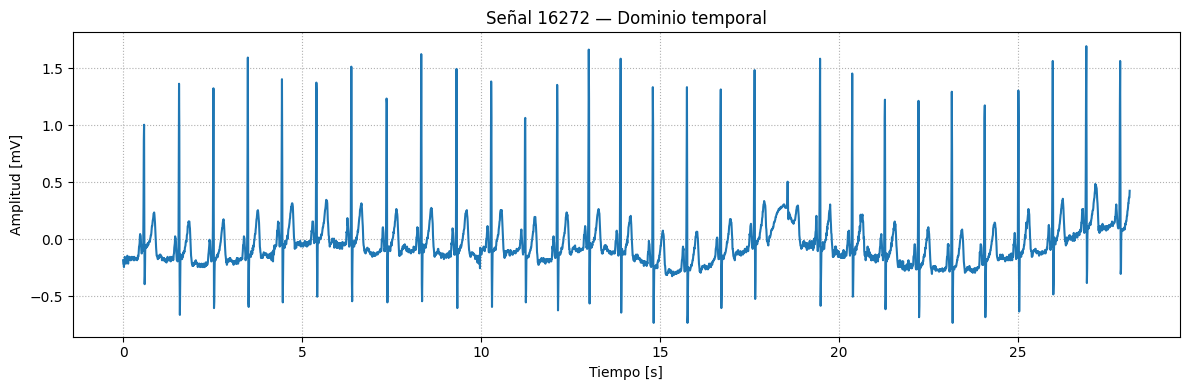

In [70]:
# ============================================
# DOMINIO TEMPORAL — REGISTRO
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


**Transformada Rápida de Fourier (FFT)
La FFT permite transformar una señal del dominio temporal al dominio frecuencial.**

Antes de calcularla consideraremos dos casos:

Caso A — señal original
[ x[n] ]

Caso B — señal sin componente DC
[ x_{AC}[n]=x[n]-\overline{x} ]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de 0 Hz en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.

In [71]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )

In [72]:
# ============================================
#FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )

16272: frecuencia máxima analizada = 64.00 Hz


**FFT de la señal original y de la señal sin DC
Para cada registro se mostrarán dos espectros:**

1 FFT con componente DC

2FFT después de eliminar la media
El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.

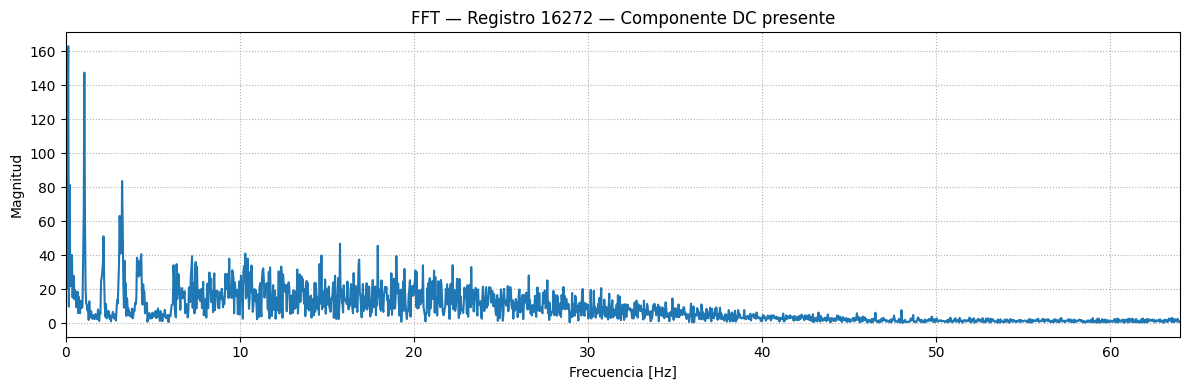

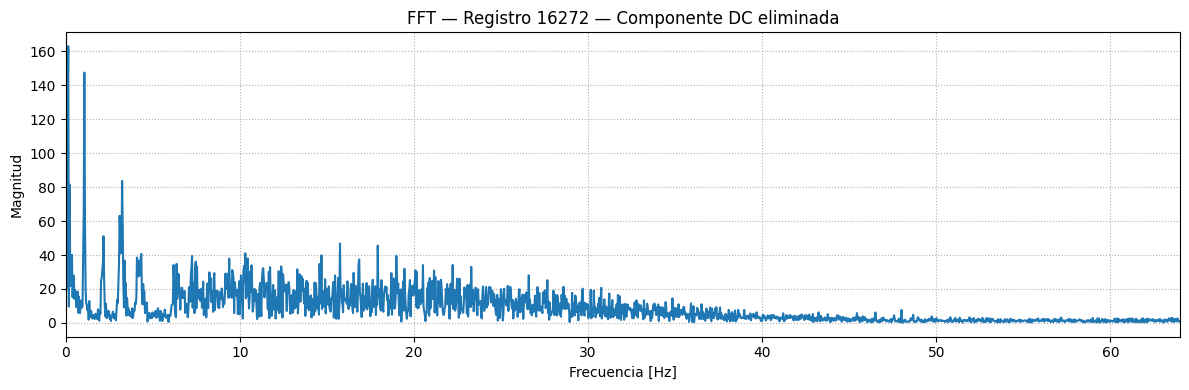

In [73]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

Preguntas de análisis
¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?

El pico exacto en 0 Hz (el "offset" o valor promedio de la señal) desaparece, porque x - media(x) fuerza a que la componente de frecuencia cero sea nula. Sin embargo, mirando tus dos gráficas verás que siguen viéndose casi idénticas, con un pico enorme (165) pegado al eje Y. Eso es clave: ese pico no es DC puro, sino energía de muy baja frecuencia (tu propio código encontró el máximo en 0.142 Hz). Es decir, restar la media elimina el offset constante, pero no elimina la deriva de línea base (baseline wander) típica del ECG, causada por la respiración o el movimiento del paciente/electrodos.

¿Qué diferencias observa entre los espectros de los tres registros?

Con un solo registro no puedo comparar. Lo que sí puedo decirte de 16272: tiene un pico dominante muy cerca de 0 Hz, un pico claro en ~1 Hz (magnitud ≈148) y otro en 3 Hz (magnitud ≈85), y luego una zona de energía moderada y ruidosa entre 5–25 Hz que decae progresivamente hacia 40–64 Hz. Si tienes los otros dos registros, compara: (a) dónde cae el pico "cardiaco" principal (relacionado con la frecuencia cardiaca promedio), (b) qué tan "limpio" o ruidoso es el espectro en la banda 5–25 Hz (indicador de ruido muscular/artefactos), y (c) si hay componentes de 50/60 Hz (interferencia de red eléctrica).

¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?

Prácticamente toda la energía relevante está por debajo de ~25–30 Hz: el pico más fuerte está en frecuencias muy bajas (menores de 0.5 Hz, deriva de línea base), luego el complejo QRS aporta energía principalmente entre ~5–20 Hz, y por encima de 30–40 Hz la magnitud cae a un nivel casi plano (ruido de alta frecuencia). Esto es típico de una señal ECG.

¿Por qué la FFT no conserva directamente la información temporal?

Porque la FFT calcula, para cada frecuencia, cuánto "aporta" esa senoide a toda la señal completa (los 28 s), colapsando el eje temporal en el cálculo. Un coeficiente de la FFT es un solo número complejo que resume la contribución de esa frecuencia a lo largo de todo el registro; no te dice si esa frecuencia estuvo presente al inicio, al final o distribuida uniformemente. Dos señales con exactamente el mismo contenido en frecuencia, pero con los eventos ocurriendo en instantes distintos, producen la misma FFT.

¿Qué ventaja ofrece observar una señal en el dominio frecuencial?

Permite identificar componentes que no son evidentes en el tiempo: el ritmo fundamental de la señal, armónicos, ruido de red eléctrica, artefactos de baja frecuencia, o la banda donde realmente vive la información útil (para diseñar filtros, por ejemplo un pasa-banda 0.5–40 Hz para limpiar un ECG). También facilita comparar cuantitativamente registros distintos con pocos números (frecuencia dominante, ancho de banda de energía), en vez de comparar formas de onda completas.

**Identificación de la frecuencia dominante**

In [74]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096


**STFT — Transformada de Fourier de Tiempo Corto**

La FFT proporciona información sobre el contenido frecuencial global de una señal.


In [75]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx

**STFT de los registros**
Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

In [76]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16272": 32,
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )

16272: nperseg = 32, ventanas calculadas = 226


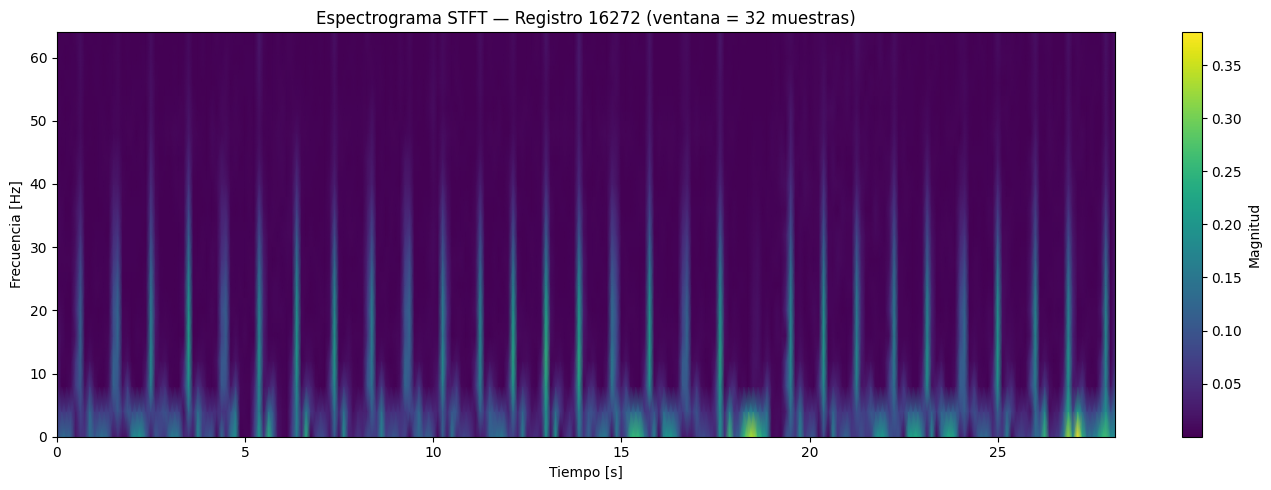

In [77]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


Preguntas de análisis

¿Qué información adicional proporciona la STFT respecto a la FFT?

La FFT te da un espectro global "aplanado" en el tiempo; la STFT agrega el eje temporal, mostrando cuándo ocurre cada componente de frecuencia. En tu espectrograma esto se ve clarísimo: en vez de un solo número por frecuencia, tienes una imagen tiempo-frecuencia donde se distinguen eventos puntuales.

¿En qué momentos se observan cambios de energía?

En tu espectrograma se ven franjas verticales brillantes que se repiten periódicamente cada ~0.8–1.2 s a lo largo de los 28 s — esos son los latidos (complejos QRS), que producen un pulso de energía de banda ancha (desde ~0 Hz hasta más de 40–60 Hz) en cada ciclo cardiaco, coherente con un ritmo sinusal normal (NSRDB). Fuera de esas franjas, la energía cae y queda concentrada solo en la banda baja (0–5 Hz), correspondiente a la línea base. Hay además dos momentos con energía visiblemente más intensa en baja frecuencia, alrededor de t≈18–19 s y t≈27 s, que podrían corresponder a un latido de mayor amplitud o a un pequeño artefacto de movimiento.

¿Qué diferencias observa entre los tres espectrogramas?

De nuevo, solo tengo el de 16272. Si comparas con tus otros dos, fíjate en: la regularidad del espaciado entre franjas (ritmo más o menos constante = más "sano"/regular), el ancho de banda que alcanza cada latido, y si aparecen bandas horizontales continuas (indicarían ruido de frecuencia fija, como interferencia de línea eléctrica) en vez de solo franjas verticales periódicas.

¿Por qué el registro 16272 utiliza una ventana de 32 muestras?

Con fs = 128 Hz, una ventana de 32 muestras equivale a 32/128 = 0.25 s. El QRS de un ECG dura típicamente menos de 100–120 ms, así que se necesita una ventana corta para poder "atrapar" ese evento rápido sin promediarlo con el resto del ciclo cardiaco; una ventana de 256 muestras (2 s) sería demasiado ancha y mezclaría varios latidos en una sola rebanada temporal, perdiendo la localización precisa de cada QRS. Por eso el enunciado usa una ventana pequeña específicamente para este registro: prioriza resolución temporal sobre resolución en frecuencia.

¿Qué podría ocurrir si se utiliza una ventana demasiado grande?

Se pierde resolución temporal: eventos rápidos y localizados (como el QRS) quedarían "promediados" dentro de una ventana que abarca varios latidos o varias fases del ciclo cardiaco, y el espectrograma mostraría bandas horizontales borrosas en vez de franjas verticales nítidas — ya no podrías decir en qué instante exacto ocurrió cada evento. A cambio, ganarías mejor resolución en frecuencia (picos más finos y precisos).

¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?

Ocurre lo contrario: ganas resolución temporal (localizas muy bien cuándo pasa cada evento) pero pierdes resolución en frecuencia, porque una ventana muy corta contiene pocas muestras y el cálculo de FFT sobre ella tiene componentes de frecuencia muy separadas entre sí (poca precisión, "borroneo" espectral). Además, si la ventana es extremadamente pequeña puede no contener ciclos completos de las frecuencias de interés, generando fugas espectrales (spectral leakage) y un espectrograma ruidoso. Este es el clásico compromiso (trade-off) tiempo-frecuencia que menciona tu propio notebook: no puedes tener resolución perfecta en ambos dominios a la vez (principio de incertidumbre tiempo-frecuencia).

**Conclusiones**

El análisis multidominio es indispensable para la caracterización completa de señales fisiológicas: el dominio del tiempo cuantifica intervalos y amplitudes, el dominio frecuencial (FFT) identifica la distribución de energía y limpia artefactos como la componente DC, y el dominio tiempo-frecuencia (STFT) permite monitorear la dinámica temporal de eventos cardiacos específicos.

La frecuencia de muestreo de $128\text{ Hz}$ cumple holgadamente con el Teorema de Nyquist-Shannon ($f_s > 2 f_{máx}$) para la captura precisa de la frecuencia cardiaca fundamental, permitiendo una reconstrucción sin aliasing del registro sinusal analizado.

# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
